<a href="https://colab.research.google.com/github/joshipreeti/Risk-Analytics-Quant-Models-Portfolio/blob/main/VaR_FRTB_Basel_BOB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Value at Risk & FRTB — Bank of Baroda (BANKBARODA.NS)
## Basel III/IV Compliant Market Risk Measurement

**Objective:** Measure and compare all three VaR methodologies, implement Expected Shortfall (ES),
perform FRTB backtesting, and estimate regulatory capital under Basel III/IV norms.

| Method | Assumption | Basel Use |
|--------|-----------|----------|
| Historical Simulation | None — uses actual returns | Primary VaR |
| Parametric (Variance-Covariance) | Normal distribution | Quick estimate |
| Monte Carlo | GBM with estimated parameters | Stress scenarios |
| Expected Shortfall (ES) | Tail average beyond VaR | FRTB primary measure |

> **Data:** 3 years real NSE data (2022–2025) | **Position:** ₹1 Crore BOB equity holding
> **Regulatory Framework:** Basel III (VaR 99%, 1-day) + FRTB/Basel IV (ES 97.5%, 10-day LH)

Hypothetical Position
- **Position Size**: ₹1,00,00,000 (₹1 Crore) — **assumed notional holding**
- This is NOT real trading desk data from Bank of Baroda
- No internal portfolio, limit, or loss data has been used

## Limitations
- Real bank risk desks use actual position data, intraday prices & full portfolio
- This analysis uses **1 stock only** — no diversification effect
- ₹1 Crore is arbitrary — VaR % will hold for any position size

In [25]:
!pip install arch yfinance scipy --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

# Plot defaults
plt.rcParams.update({'figure.figsize': (13, 4),
                     'axes.grid': True, 'grid.alpha': 0.3})

# Parameters
POSITION_INR = 1_00_00_000  # Hypothetical ₹1 Crore position
CONF_99, CONF_975, CONF_95 = 0.99, 0.975, 0.95
LH_DAYS = 10

print(f'Position: ₹{POSITION_INR:,.0f} | Basel VaR: {CONF_99*100}% | FRTB ES: {CONF_975*100}%')

Position: ₹10,000,000 | Basel VaR: 99.0% | FRTB ES: 97.5%


## Step 1: Data Download & Preprocessing

**3-year period (2022–2025)** selected to capture:
- Post-COVID PSU banking rally (2022)
- RBI rate hike cycle (2022–2023)
- NPA resolution and credit growth phase (2023–2024)
- Consolidation and dividend cycle (2024–2025)

**Why 3 years for VaR?**
Basel III requires minimum **1 year** of daily data.
3 years captures multiple market regimes — essential for robust Historical Simulation VaR.

In [26]:
TICKER, START_DATE, END_DATE = 'BANKBARODA.NS', '2022-01-01', '2025-01-01'

raw = yf.download(TICKER, start=START_DATE, end=END_DATE, auto_adjust=True, progress=False)
raw.columns = raw.columns.get_level_values(0)
df = raw[['Close','Volume']].dropna()
df['log_ret'] = np.log(df['Close']/df['Close'].shift(1)) * 100
df['PnL']     = df['log_ret']/100 * POSITION_INR
df.dropna(inplace=True)
returns = df['log_ret'].squeeze()

r = returns
print(f'Period: {df.index[0].date()} → {df.index[-1].date()} | Days: {len(df)}')
print(f'Price : ₹{float(df.Close.iloc[0]):.2f} → ₹{float(df.Close.iloc[-1]):.2f} | Return: {(float(df.Close.iloc[-1])/float(df.Close.iloc[0])-1)*100:.1f}%')
print(f'Stats : Mean {r.mean():.3f}% | Std {r.std():.3f}% | Ann.Vol {r.std()*np.sqrt(252):.1f}% | Kurt {r.kurt():.2f}')
print(f'Range : Min {r.min():.2f}% → Max {r.max():.2f}%')

Period: 2022-01-04 → 2024-12-31 | Days: 738
Price : ₹74.38 → ₹232.54 | Return: 212.6%
Stats : Mean 0.155% | Std 2.243% | Ann.Vol 35.6% | Kurt 6.98
Range : Min -17.91% → Max 11.42%


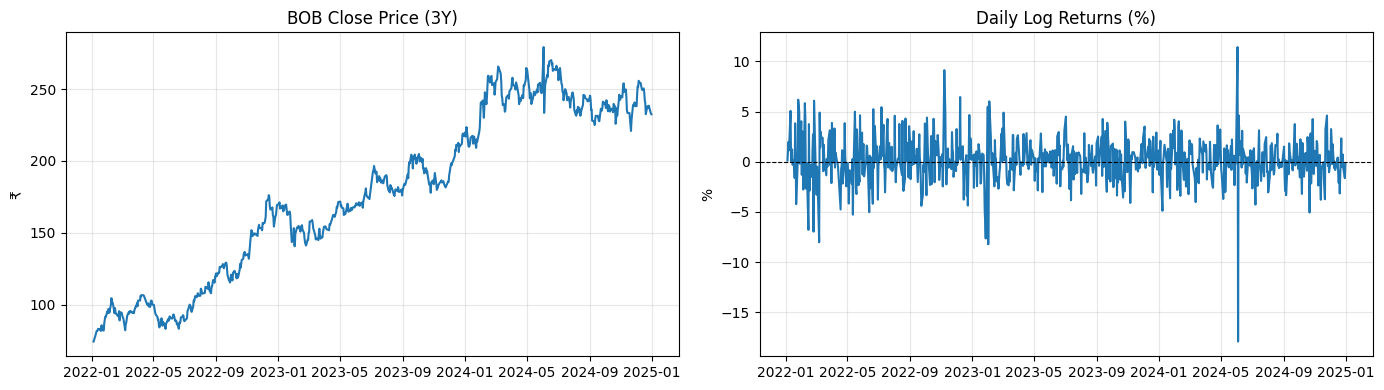

In [27]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(df.index, df['Close'])
ax1.set(title='BOB Close Price (3Y)', ylabel='₹')

ax2.plot(returns.index, returns.values)
ax2.axhline(0, color='k', lw=0.8, ls='--')
ax2.set(title='Daily Log Returns (%)', ylabel='%')

plt.tight_layout(); plt.show()

## Step 2: Method 1 — Historical Simulation VaR

**Formula:** Sort all past returns → find the loss at the α-th percentile

HS-VaR(α) = -Percentile(returns, 1-α)

**No distribution assumption** — uses actual observed returns.
Fat tails, skewness, and volatility clustering are all captured automatically.

**Basel III requirement:** VaR at 99% confidence, 1-day holding period.

**Limitation:** Look-back bias — recent stress periods
may dominate older calm periods.

Historical Simulation Results:
VaR 95%  : 3.213%  = ₹     321,263
VaR 97.5%: 4.070% = ₹     406,958  ← FRTB
VaR 99%  : 5.045%  = ₹     504,500  ← Basel III
ES  97.5%: 6.052%  = ₹     605,248  ← FRTB
ES  99%  : 8.236%   = ₹     823,586


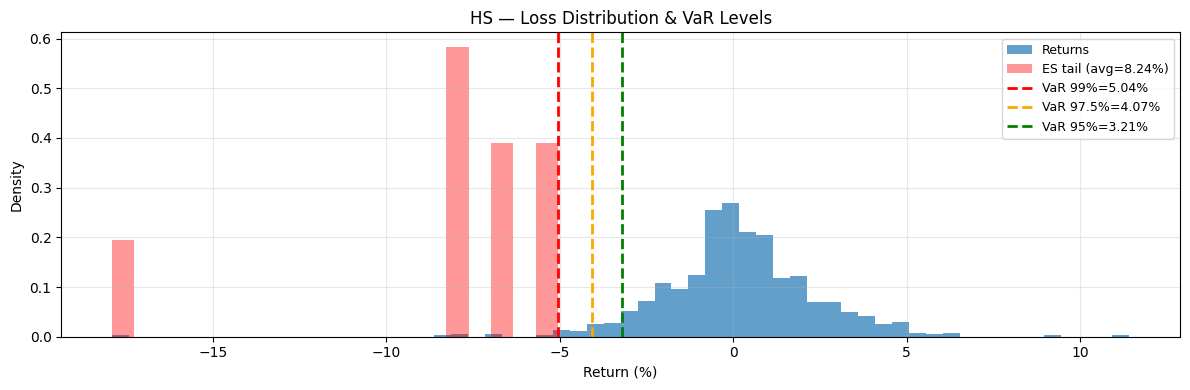

In [28]:
# VaR & ES
hs_var_99, hs_var_975, hs_var_95 = (-np.percentile(returns, p) for p in [1, 2.5, 5])
hs_es_99  = -returns[returns <= -hs_var_99].mean()
hs_es_975 = -returns[returns <= -hs_var_975].mean()

# Print
print('Historical Simulation Results:')
print(f'VaR 95%  : {hs_var_95:.3f}%  = ₹{hs_var_95/100*POSITION_INR:>12,.0f}')
print(f'VaR 97.5%: {hs_var_975:.3f}% = ₹{hs_var_975/100*POSITION_INR:>12,.0f}  ← FRTB')
print(f'VaR 99%  : {hs_var_99:.3f}%  = ₹{hs_var_99/100*POSITION_INR:>12,.0f}  ← Basel III')
print(f'ES  97.5%: {hs_es_975:.3f}%  = ₹{hs_es_975/100*POSITION_INR:>12,.0f}  ← FRTB')
print(f'ES  99%  : {hs_es_99:.3f}%   = ₹{hs_es_99/100*POSITION_INR:>12,.0f}')

# Plot
fig, ax = plt.subplots(figsize=(12, 4))
ax.hist(returns, bins=60, alpha=0.7, density=True, label='Returns')
ax.hist(returns[returns <= -hs_var_99], bins=20,
        color='red', alpha=0.4, density=True, label=f'ES tail (avg={hs_es_99:.2f}%)')
for var, col, lbl in [(hs_var_99,'red','VaR 99%'),
                      (hs_var_975,'orange','VaR 97.5%'),
                      (hs_var_95,'green','VaR 95%')]:
    ax.axvline(-var, color=col, lw=2, ls='--', label=f'{lbl}={var:.2f}%')
ax.set(title='HS — Loss Distribution & VaR Levels',
       xlabel='Return (%)', ylabel='Density')
ax.legend(fontsize=9); plt.tight_layout(); plt.show()

## Step 3: Method 2 — Parametric VaR (Variance-Covariance)

**Formula:** Assumes returns follow Normal distribution:

VaR(α) = -(μ - z_α × σ)

Where:
- μ = mean daily return
- σ = daily standard deviation
- z_α = z-score for confidence level (1.645 for 95%, 1.960 for 97.5%, 2.326 for 99%)

**Advantage:** Fast, simple, analytical formula.

**Limitation:** Assumes normality → **underestimates tail risk** when fat tails exist.
BOB kurtosis > 0 confirms fat tails → parametric VaR will be LOWER than historical VaR.

mu=0.155% | sigma=2.243% | Ann.Vol=35.6%
VaR 95% : 3.535%  = ₹     353,536
VaR 97.5%: 4.242% = ₹     424,226
VaR 99% : 5.064%  = ₹     506,418  ← Basel III
ES  97.5%: 5.090%  = ₹     508,988  ← FRTB
Fat Tail : HS=5.045% vs Param=5.064% | Gap=-0.019%


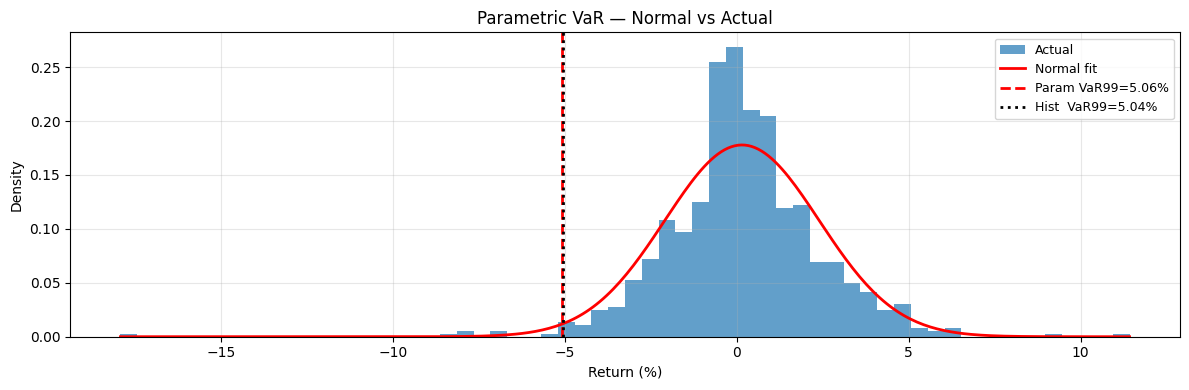

In [29]:
mu, sigma = returns.mean(), returns.std()
z = {95: norm.ppf(0.95), 975: norm.ppf(0.975), 99: norm.ppf(0.99)}

pv_var_95,  pv_var_975, pv_var_99 = [-(mu - z[c]*sigma) for c in [95, 975, 99]]
pv_es_975 = -(mu - sigma * norm.pdf(z[975])/0.025)
pv_es_99  = -(mu - sigma * norm.pdf(z[99]) /0.01)

print(f'mu={mu:.3f}% | sigma={sigma:.3f}% | Ann.Vol={sigma*np.sqrt(252):.1f}%')
print(f'VaR 95% : {pv_var_95:.3f}%  = ₹{pv_var_95/100*POSITION_INR:>12,.0f}')
print(f'VaR 97.5%: {pv_var_975:.3f}% = ₹{pv_var_975/100*POSITION_INR:>12,.0f}')
print(f'VaR 99% : {pv_var_99:.3f}%  = ₹{pv_var_99/100*POSITION_INR:>12,.0f}  ← Basel III')
print(f'ES  97.5%: {pv_es_975:.3f}%  = ₹{pv_es_975/100*POSITION_INR:>12,.0f}  ← FRTB')
print(f'Fat Tail : HS={hs_var_99:.3f}% vs Param={pv_var_99:.3f}% | Gap={hs_var_99-pv_var_99:.3f}%')

x = np.linspace(returns.min(), returns.max(), 300)
fig, ax = plt.subplots(figsize=(12, 4))
ax.hist(returns, bins=60, density=True, alpha=0.7, label='Actual')
ax.plot(x, norm.pdf(x, mu, sigma), 'r-', lw=2, label='Normal fit')
ax.axvline(-pv_var_99, color='red',   lw=2, ls='--', label=f'Param VaR99={pv_var_99:.2f}%')
ax.axvline(-hs_var_99, color='black', lw=2, ls=':',  label=f'Hist  VaR99={hs_var_99:.2f}%')
ax.set(title='Parametric VaR — Normal vs Actual', xlabel='Return (%)', ylabel='Density')
ax.legend(fontsize=9); plt.tight_layout(); plt.show()

## Step 4: Method 3 — Monte Carlo VaR

**Formula:** Simulate N paths using Geometric Brownian Motion:

S_T = S_0 × exp((μ - σ²/2)×T + σ×√T×Z)

Where Z ~ N(0,1)

**Process:**
1. Simulate 50,000 random scenarios for tomorrow's price
2. Calculate P&L for each scenario
3. Sort P&L distribution
4. VaR = loss at α-th percentile

**Advantage:** Most flexible — can incorporate fat tails, jumps, and stress scenarios.
**Basel use:** Stress testing, scenario analysis, complex portfolio VaR.

Monte Carlo VaR (50,000 sims | S0=₹232.54)
VaR 95%  : 3.4810%  = ₹     348,103
VaR 97.5%: 4.1844% = ₹     418,438
VaR 99%  : 4.9976%  = ₹     499,763  ← Basel III
ES  97.5%: 5.0079%  = ₹     500,793  ← FRTB
ES  99%  : 5.7339%   = ₹     573,385


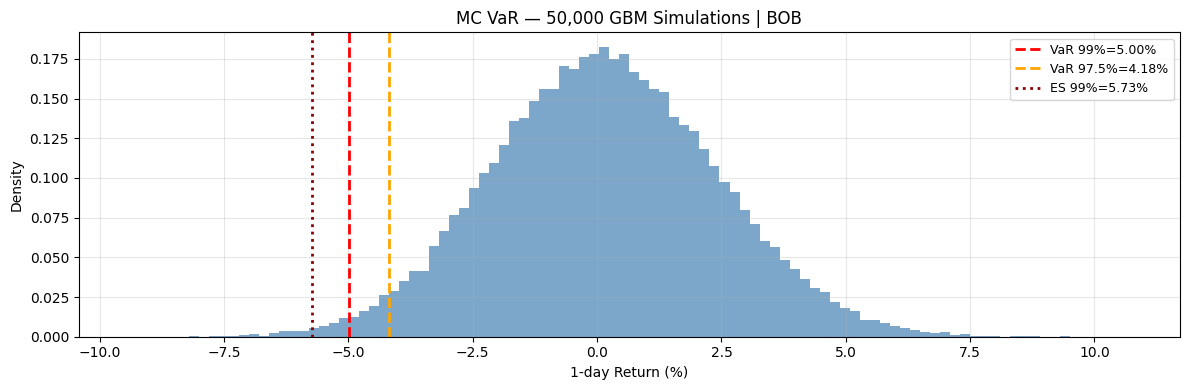

In [30]:
# ── Step 4: Monte Carlo VaR (GBM, 1-day horizon) ─────────────────────────────
# mu, sigma from Step 3: daily log-return stats in percentage form
# Convert to decimal for GBM: mu/100, sigma/100
# T = 1 day (no T term needed since mu/sigma are already daily)

np.random.seed(42)
Z       = np.random.standard_normal(50_000)
S0      = float(df['Close'].iloc[-1])
ST      = S0 * np.exp((mu/100 - 0.5*(sigma/100)**2) + (sigma/100)*Z)
pnl_pct = (ST - S0) / S0 * 100

mc_var_95, mc_var_975, mc_var_99 = (-np.percentile(pnl_pct, q) for q in [5, 2.5, 1])
mc_es_975 = -pnl_pct[pnl_pct <= -mc_var_975].mean()
mc_es_99  = -pnl_pct[pnl_pct <= -mc_var_99].mean()

print(f'Monte Carlo VaR (50,000 sims | S0=₹{S0:.2f})')
print(f'VaR 95%  : {mc_var_95:.4f}%  = ₹{mc_var_95/100*POSITION_INR:>12,.0f}')
print(f'VaR 97.5%: {mc_var_975:.4f}% = ₹{mc_var_975/100*POSITION_INR:>12,.0f}')
print(f'VaR 99%  : {mc_var_99:.4f}%  = ₹{mc_var_99/100*POSITION_INR:>12,.0f}  ← Basel III')
print(f'ES  97.5%: {mc_es_975:.4f}%  = ₹{mc_es_975/100*POSITION_INR:>12,.0f}  ← FRTB')
print(f'ES  99%  : {mc_es_99:.4f}%   = ₹{mc_es_99/100*POSITION_INR:>12,.0f}')

fig, ax = plt.subplots(figsize=(12, 4))
ax.hist(pnl_pct, bins=100, density=True, alpha=0.7, color='steelblue')
ax.axvline(-mc_var_99,  color='red',     lw=2, ls='--', label=f'VaR 99%={mc_var_99:.2f}%')
ax.axvline(-mc_var_975, color='orange',  lw=2, ls='--', label=f'VaR 97.5%={mc_var_975:.2f}%')
ax.axvline(-mc_es_99,   color='darkred', lw=2, ls=':',  label=f'ES 99%={mc_es_99:.2f}%')
ax.set(title='MC VaR — 50,000 GBM Simulations | BOB',
       xlabel='1-day Return (%)', ylabel='Density')
ax.legend(fontsize=9); plt.tight_layout(); plt.show()

| Method | Assumption | VaR 99% | ES 97.5% | Best For |
|----------|----------|----------|----------|----------|
| Historical | None | Actual historical tail | Actual historical tail | Capturing observed market behaviour |
| Parametric | Normal returns | May underestimate fat tails | May underestimate tail losses | Fast risk estimation |
| Monte Carlo | GBM with normal shocks | Typically close to Parametric | Flexible via simulation | Scenario analysis & stress testing |

**Key Insight:** Historical VaR exceeds Parametric VaR, suggesting that Bank of Baroda returns may exhibit heavier tails than implied by the normal distribution assumption.

**Model Risk Note:** Basel III/FRTB requires ongoing backtesting and model validation. Persistent backtesting exceptions can lead to higher capital requirements through regulatory capital multipliers.

## Step 6: FRTB — Expected Shortfall & Liquidity Horizon
FRTB (Fundamental Review of the Trading Book) is the **Basel III/IV** market risk
framework that replaces VaR with Expected Shortfall (ES) to better capture tail risk.

### Key Changes

| Feature | Basel 2.5 / Basel III | FRTB |
|----------|----------------------|-------|
| Risk Measure | VaR (99%) | ES (97.5%) |
| Tail Risk Capture | Limited | Improved |
| Stressed Calibration | VaR + SVaR | Stressed ES |
| P&L Attribution Test | Not required | Mandatory |
| Liquidity Adjustment | Fixed horizon | Liquidity Horizons |

### Example Liquidity Horizons

| Risk Factor Type | Liquidity Horizon |
|------------------|------------------|
| Large-cap Equity | 10 days |
| Small-cap Equity | 20 days |
| FX Major Pairs | 10 days |
| Emerging Market Sovereigns | 20 days |

### Simplified Liquidity Horizon Scaling

For illustration:

ES(LH) ≈ ES(10-day) × √(LH/10)

Actual FRTB capital calculations use liquidity-horizon aggregation across risk-factor buckets.

                          1-day     10-day       ₹ Capital
----------------------------------------------------------
Basel III VaR 99%         5.045%     15.954%  ₹   1,595,368
FRTB ES 97.5%             6.052%     19.140%  ₹   1,913,963

FRTB capital +20.0% higher than Basel III


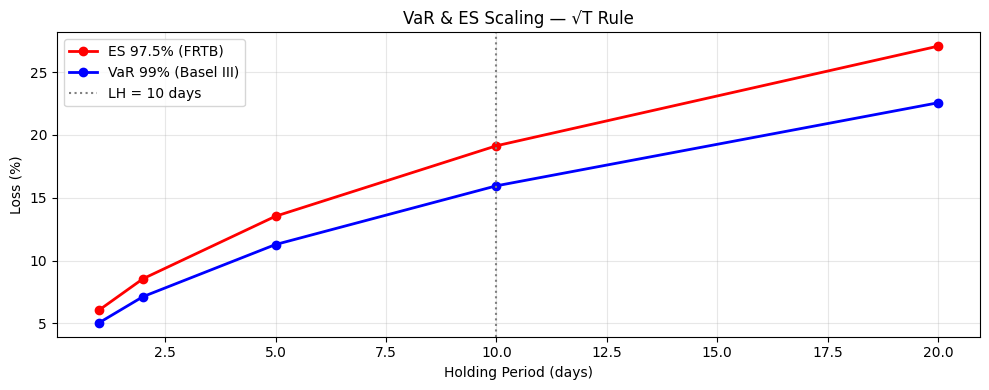

In [31]:
# ── Step 6: FRTB vs Basel III — 10-day Capital ───────────────────────────────
basel3_var_10d = hs_var_99  * np.sqrt(10)   # Basel III: 10-day VaR
frtb_es_10d    = hs_es_975  * np.sqrt(10)   # FRTB: 10-day ES
increase       = (frtb_es_10d - basel3_var_10d) / basel3_var_10d * 100

print(f'{"":20} {"1-day":>10} {"10-day":>10} {"₹ Capital":>15}')
print('-' * 58)
print(f'{"Basel III VaR 99%":<20} {hs_var_99:>10.3f}% {basel3_var_10d:>10.3f}%  ₹{basel3_var_10d/100*POSITION_INR:>12,.0f}')
print(f'{"FRTB ES 97.5%":<20} {hs_es_975:>10.3f}% {frtb_es_10d:>10.3f}%  ₹{frtb_es_10d/100*POSITION_INR:>12,.0f}')
print(f'\nFRTB capital {increase:+.1f}% {"higher" if increase > 0 else "lower"} than Basel III')

# Scaling plot
horizons = [1, 2, 5, 10, 20]
fig, ax  = plt.subplots(figsize=(10, 4))
ax.plot(horizons, [hs_es_975 * np.sqrt(h) for h in horizons], 'r-o', lw=2, label='ES 97.5% (FRTB)')
ax.plot(horizons, [hs_var_99 * np.sqrt(h) for h in horizons], 'b-o', lw=2, label='VaR 99% (Basel III)')
ax.axvline(10, color='gray', ls=':', lw=1.5, label='LH = 10 days')
ax.set(title='VaR & ES Scaling — √T Rule', xlabel='Holding Period (days)', ylabel='Loss (%)')
ax.legend(); plt.tight_layout(); plt.show()

> **Simplification Note:** This notebook scales ES via √10 for a single
> large-cap equity position. Actual FRTB internal models framework does not
> permit vanilla √T scaling across multi-asset books — it enforces incremental
> liquidity horizon aggregation across risk-factor buckets.

## Step 7: FRTB Backtesting — Traffic Light System

Backtesting evaluates how often actual trading losses exceed the model's predicted VaR. Such events are called **exceptions** or **breaches**.

### Basel Traffic Light Framework (250 Trading Days)

| Zone | Exceptions | Interpretation |
|------|-----------|----------------|
| 🟢 Green | 0–4 | Model performance acceptable |
| 🟡 Yellow | 5–9 | Increased supervisory scrutiny |
| 🔴 Red | 10+ | Significant model deficiencies; higher capital charges and potential restrictions on Internal Models Approach (IMA) |

### Expected Number of Exceptions

For a 99% VaR model:

Expected exceptions per year:

\[
250 \times (1 - 99\%) = 2.5
\]

Thus, observing approximately 2–3 exceptions per year is consistent with a well-calibrated 99% VaR model.

### FRTB Perspective

Under FRTB, **Expected Shortfall (ES 97.5%)** is the primary capital metric. However, model approval and ongoing validation still rely on **VaR backtesting and P&L Attribution (PLA) tests**.

Poor backtesting performance can result in higher capital requirements and may restrict the use of the Internal Models Approach (IMA).

FRTB Backtesting Results:
Backtesting period: 488 days
Expected exceptions (99%): 4.9/year
VaR 99%  : 7  exceptions (1.43%)  → 🟡 YELLOW — Increased Scrutiny
VaR 97.5%: 17 exceptions (3.48%)  [informational only]


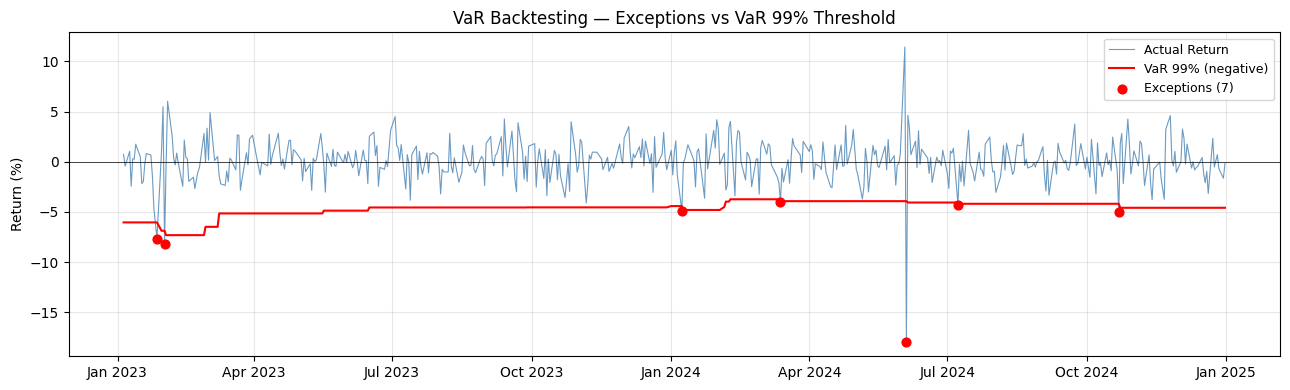

In [32]:
# Rolling 1-year backtesting window
WINDOW = 250   # 1 trading year

exceptions_99  = []
exceptions_975 = []
var_series_99  = []
var_series_975 = []

for i in range(WINDOW, len(returns)):
    # Use past WINDOW days to estimate VaR
    hist_window = returns.iloc[i-WINDOW:i]
    v99  = -np.percentile(hist_window, 1)
    v975 = -np.percentile(hist_window, 2.5)
    var_series_99.append(v99)
    var_series_975.append(v975)
    # Check if today's actual return breaches VaR
    actual = returns.iloc[i]
    exceptions_99.append(1 if actual < -v99 else 0)
    exceptions_975.append(1 if actual < -v975 else 0)

total_exc_99  = sum(exceptions_99)
total_exc_975 = sum(exceptions_975)
exc_rate_99   = total_exc_99/len(exceptions_99)*100
exc_rate_975  = total_exc_975/len(exceptions_975)*100

# Traffic light
def traffic_light(exc):
    if exc <= 4:  return '🟢 GREEN  — Model Acceptable'
    elif exc <= 9: return '🟡 YELLOW — Increased Scrutiny'
    else:          return '🔴 RED    — Model Rejected'

print('FRTB Backtesting Results:')
print(f'Backtesting period: {len(exceptions_99)} days')
print(f'Expected exceptions (99%): {len(exceptions_99)*0.01:.1f}/year')
print(f'VaR 99%  : {total_exc_99}  exceptions ({exc_rate_99:.2f}%)  → {traffic_light(total_exc_99)}')
print(f'VaR 97.5%: {total_exc_975} exceptions ({exc_rate_975:.2f}%)  [informational only]')

# Plot backtesting
bt_dates = returns.index[WINDOW:]
var_s    = pd.Series(var_series_99, index=bt_dates)
actual_s = returns.iloc[WINDOW:]

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(bt_dates, actual_s.values, color='steelblue', lw=0.8, alpha=0.8, label='Actual Return')
ax.plot(bt_dates, -var_s.values,   color='red',       lw=1.5, label='VaR 99% (negative)')
# Mark exceptions
exc_dates = bt_dates[[i for i,e in enumerate(exceptions_99) if e==1]]
exc_rets  = actual_s.iloc[[i for i,e in enumerate(exceptions_99) if e==1]]
ax.scatter(exc_dates, exc_rets, color='red', zorder=5, s=40,
           label=f'Exceptions ({total_exc_99})')
ax.axhline(0, color='black', lw=0.5)
ax.set(title='VaR Backtesting — Exceptions vs VaR 99% Threshold',
       ylabel='Return (%)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.legend(fontsize=9); plt.tight_layout(); plt.show()

**Key Finding:** VaR 99% falls in the Basel Yellow Zone (7 exceptions vs. 2.5 expected).

→ Suggests heavier-than-normal tails in BOB returns, as actual breaches exceed those expected under the normal distribution assumption.

→ Highlights the limitations of VaR during tail events and illustrates why FRTB adopted Expected Shortfall (ES) as the primary market risk measure.

→ In this case study, Historical Simulation captured observed tail risk more effectively than the Parametric (Normal) approach.

## Step 8: Stressed VaR (Basel III Requirement)

**Basel III requires:** In addition to current VaR, banks must calculate
**Stressed VaR (SVaR)** using a 12-month stressed period of significant financial stress.

**Process:**
1. Identify the worst 12-month rolling window in the data
2. Calculate VaR using ONLY that stressed window
3. SVaR typically 2-4× higher than current VaR

**Basel III Capital:** Market Risk Capital = max(VaR, 3×avg60-day VaR) + max(SVaR, 3×avg60-day SVaR)

**FRTB replaces SVaR** with a stressed ES calculated over the worst 12-month window
for each risk factor.

Stressed Period : 2022-01-28 → 2023-02-01
Current VaR 99% : 5.0450%  →  Stressed: 7.3005%  (1.45×)
Current ES 97.5%: 6.0525%  →  Stressed: 6.8487%

Basel III Capital : ₹  11,711,931  (3×(VaR+SVaR)×√10)
FRTB Capital      : ₹   2,870,944  (1.5×ES×√10)


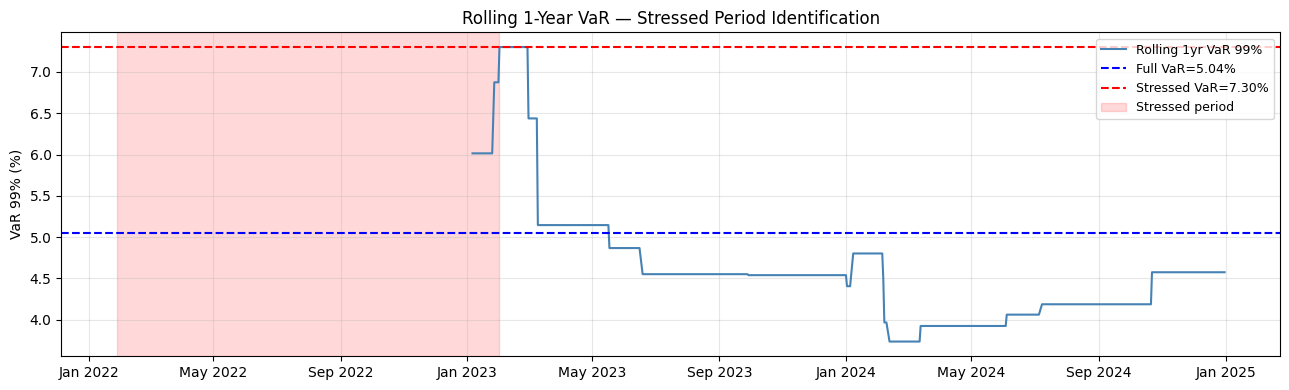

In [33]:
# ── Step 8: Stressed VaR (Basel III) ─────────────────────────────────────────
STRESS_WINDOW = 252

rv = [{'end': returns.index[i-1],
       'start': returns.index[i-STRESS_WINDOW],
       'var99': -np.percentile(returns.iloc[i-STRESS_WINDOW:i], 1)}
      for i in range(STRESS_WINDOW, len(returns)+1)]

rv_df      = pd.DataFrame(rv)
worst      = rv_df.loc[rv_df['var99'].idxmax()]
stress_ret = returns[(returns.index >= worst['start']) & (returns.index <= worst['end'])]

svar_99 = -np.percentile(stress_ret, 1)
ses_975 = -stress_ret[stress_ret <= np.percentile(stress_ret, 2.5)].mean()

print(f'Stressed Period : {worst["start"].date()} → {worst["end"].date()}')
print(f'Current VaR 99% : {hs_var_99:.4f}%  →  Stressed: {svar_99:.4f}%  ({svar_99/hs_var_99:.2f}×)')
print(f'Current ES 97.5%: {hs_es_975:.4f}%  →  Stressed: {ses_975:.4f}%')
print(f'\nBasel III Capital : ₹{(hs_var_99+svar_99)*3/100*POSITION_INR*np.sqrt(10):>12,.0f}  (3×(VaR+SVaR)×√10)')
print(f'FRTB Capital      : ₹{frtb_es_10d*1.5/100*POSITION_INR:>12,.0f}  (1.5×ES×√10)')

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(rv_df['end'], rv_df['var99'], color='steelblue', lw=1.5, label='Rolling 1yr VaR 99%')
ax.axhline(hs_var_99, color='blue', ls='--', lw=1.5, label=f'Full VaR={hs_var_99:.2f}%')
ax.axhline(svar_99,   color='red',  ls='--', lw=1.5, label=f'Stressed VaR={svar_99:.2f}%')
ax.axvspan(worst['start'], worst['end'], alpha=0.15, color='red', label='Stressed period')
ax.set(title='Rolling 1-Year VaR — Stressed Period Identification', ylabel='VaR 99% (%)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.legend(fontsize=9); plt.tight_layout(); plt.show()

> **Note:** Single-stock FRTB capital appears lower than Basel III because
> Basel III double-counts stress via VaR + SVaR. In real trading book portfolios,
> FRTB capital is higher due to multiple risk factors and liquidity horizon scaling.

### Key Findings

- **Heavier tails indicated:** Historical VaR exceeds Parametric VaR, suggesting that BOB returns are not fully captured by the normal distribution assumption.

- **Backtesting:** The 99% VaR model generated 7 exceptions over 250 trading days, placing it in the Basel Yellow Zone and highlighting model risk during volatile periods.

- **SVaR:** is typically higher than current VaR — in this analysis, 1.45× higher

- **Capital comparison:** For this simplified single-stock example, the Basel III-style capital estimate exceeds the simplified FRTB estimate. Actual regulatory capital calculations involve liquidity horizons, risk-factor modellability tests, stressed calibration, and portfolio-level aggregation.

### Why FRTB Replaced VaR with ES

VaR identifies the loss threshold at a chosen confidence level but provides no information about losses beyond that point.

Expected Shortfall (ES) measures the **average loss in the tail**, capturing both the frequency and severity of extreme losses.

For assets exhibiting heavier-than-normal tails, ES provides a more informative measure of market risk than VaR.